# Pilot Study: Clarifying Questions as Signals of Internal Uncertainty

This notebook tests whether the clarifying questions generated by an LLM can distinguish between two types of internal uncertainty:

- **Epistemic**: the model faces a genuine knowledge gap
- **Aleatoric**: multiple valid answers exist or user context is needed
- **Unambiguous**: control group — the model should answer directly with `NO_CLARIFICATION_NEEDED`

**Model:** `gemini-2.5-flash` via the `google-genai` SDK with a Vertex AI API key.

**Workflow:**
1. Smoke test — verify the API key and model work before running anything
2. Phase 1 — generate one response per prompt at temperature=0.0, then manually label
3. Phase 2 — generate 5 responses per prompt at temperature=0.8 and measure variation
4. Phase 3 — correlate labels with variation scores and interpret results


## Requirements

```bash
pip install google-genai pandas numpy matplotlib seaborn scipy bert-score
```

Set your Vertex AI API key in a `.env` file in the project root:

```
VERTEX_API_KEY=your_key_here
```


In [17]:
from __future__ import annotations

import itertools
import json
import os
import re
import time
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from bert_score import score as bertscore_score
from IPython.display import Markdown, display
from scipy.stats import mannwhitneyu, pointbiserialr, kruskal
from google import genai
from google.genai import types

# ── Paths ──────────────────────────────────────────────────────────────────
ROOT = Path.cwd()
OUTPUT_DIR = ROOT / "outputs"
FIGURE_DIR = ROOT / "figures"
PROMPT_TEMPLATE_PATH = ROOT / "gemini_prompt_template.txt"
PROMPTS_JSON_PATH = ROOT / "study_prompts.json"
GENERATED_CQS_PATH = OUTPUT_DIR / "generated_cqs.csv"
LABELLED_CQS_PATH = OUTPUT_DIR / "labelled_cqs.csv"
VARIATION_RUNS_PATH = OUTPUT_DIR / "variation_runs.csv"
VARIATION_SCORES_PATH = OUTPUT_DIR / "variation_scores.csv"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ──────────────────────────────────────────────────────────────
MODEL_ID = "gemini-2.5-flash"
VALID_TYPES = ["epistemic", "aleatoric", "unambiguous"]
QUESTION_TYPES = ["epistemic", "aleatoric"]
NO_CLARIFICATION_TOKEN = "NO_CLARIFICATION_NEEDED"
N_VARIATION_RUNS = 4
REQUEST_INTERVAL_SECONDS = 3.0
MAX_RETRIES = 8

PHASE1_TEMPERATURE = 0.0   # deterministic canonical response
PHASE2_TEMPERATURE = 0.8   # natural stochastic variation

# ── Visual style ───────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "savefig.dpi": 300,
    "figure.dpi": 120,
})

PALETTE = {
    "epistemic": "#1f77b4",
    "aleatoric": "#ff7f0e",
    "unambiguous": "#2ca02c",
    "Agreement": "#2ca02c",
    "Disagreement": "#d62728",
}

# ── Helpers ────────────────────────────────────────────────────────────────
def save_and_show(fig: plt.Figure, filename: str) -> None:
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, bbox_inches="tight")
    plt.show()

def clean_text(text) -> str:
    if text is None:
        return ""
    return " ".join(str(text).strip().split())

def word_count(text: str) -> int:
    return len(clean_text(text).split())

def is_no_clarification(text: str) -> bool:
    return clean_text(text).upper().replace(" ", "_") == NO_CLARIFICATION_TOKEN

def normalize_model_output(text: str) -> str:
    text = clean_text(text)
    if not text:
        return ""
    if NO_CLARIFICATION_TOKEN in text.upper().replace(" ", "_"):
        return NO_CLARIFICATION_TOKEN
    text = re.sub(r"^(clarifying question|question)\s*[:\-]\s*", "", text, flags=re.IGNORECASE)
    text = text.strip(" \t\n\r\"'")
    match = re.search(r"([^?]*\?)", text)
    if match:
        text = clean_text(match.group(1))
    elif text and not text.endswith("?"):
        text = text.rstrip(".!") + "?"
    return text

def is_usable_output(text: str) -> bool:
    text = clean_text(text)
    return bool(text) and (
        text == NO_CLARIFICATION_TOKEN
        or (text.endswith("?") and text.count("?") == 1 and len(text) >= 8)
    )

def rouge_l_f1(text_a: str, text_b: str) -> float:
    tokens_a = clean_text(text_a).split()
    tokens_b = clean_text(text_b).split()
    if not tokens_a and not tokens_b:
        return 1.0
    if not tokens_a or not tokens_b:
        return 0.0
    dp = [[0] * (len(tokens_b) + 1) for _ in range(len(tokens_a) + 1)]
    for i in range(1, len(tokens_a) + 1):
        for j in range(1, len(tokens_b) + 1):
            if tokens_a[i - 1] == tokens_b[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
    lcs = dp[-1][-1]
    recall = lcs / len(tokens_a)
    precision = lcs / len(tokens_b)
    return 0.0 if recall + precision == 0 else 2 * recall * precision / (recall + precision)

print(f"Project root : {ROOT}")
print(f"Outputs      : {OUTPUT_DIR}")
print(f"Figures      : {FIGURE_DIR}")
print(f"Model        : {MODEL_ID}")
print(f"Phase 1 temp : {PHASE1_TEMPERATURE}")
print(f"Phase 2 temp : {PHASE2_TEMPERATURE}")


Project root : d:\final_project\pilot_study
Outputs      : d:\final_project\pilot_study\outputs
Figures      : d:\final_project\pilot_study\figures
Model        : gemini-2.5-flash
Phase 1 temp : 0.0
Phase 2 temp : 0.8


## API Setup


In [2]:
# Load .env if present
dotenv_path = ROOT / ".env"
if dotenv_path.exists():
    for raw_line in dotenv_path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        os.environ.setdefault(key.strip(), value.strip().strip('"').strip("'"))

VERTEX_API_KEY = os.environ.get("VERTEX_API_KEY")
if not VERTEX_API_KEY:
    raise EnvironmentError("VERTEX_API_KEY not found. Set it in your .env file or environment.")

# Initialise the client using the Vertex AI API key
client = genai.Client(
    api_key=VERTEX_API_KEY,
    http_options=types.HttpOptions(api_version="v1")
)

print("Client initialised successfully.")
print(f"Key prefix: {VERTEX_API_KEY[:8]}...")


Client initialised successfully.
Key prefix: AQ.Ab8RN...


## Smoke Test

Run this cell first to confirm your API key and model are working before starting any phase.


In [3]:
smoke_response = client.models.generate_content(
    model=MODEL_ID,
    contents="How does AI work? Answer in two sentences.",
)
print("=== Smoke Test ===")
print(smoke_response.text)
print("==================")
print("Smoke test passed — model is reachable.")


=== Smoke Test ===
AI works by analyzing vast amounts of data to identify patterns, relationships, and rules. It then uses these learned insights to make predictions, perform tasks, or generate new content, essentially mimicking human-like intelligence.
Smoke test passed — model is reachable.


## Study Inputs


In [4]:
# Load and validate the prompt template
if not PROMPT_TEMPLATE_PATH.exists():
    raise FileNotFoundError(f"Prompt template not found: {PROMPT_TEMPLATE_PATH}")
if not PROMPTS_JSON_PATH.exists():
    raise FileNotFoundError(f"Study prompts file not found: {PROMPTS_JSON_PATH}")

prompt_template = PROMPT_TEMPLATE_PATH.read_text(encoding="utf-8").strip()
if "{{USER_QUERY}}" not in prompt_template:
    raise ValueError("The prompt template must contain the placeholder {{USER_QUERY}}.")

# Load and validate the prompts
study_prompts = json.loads(PROMPTS_JSON_PATH.read_text(encoding="utf-8"))
prompts_df = pd.DataFrame(study_prompts).copy()

required_columns = {"prompt_text", "prompt_type"}
missing_columns = required_columns - set(prompts_df.columns)
if missing_columns:
    raise ValueError(f"study_prompts.json is missing required keys: {sorted(missing_columns)}")
if len(prompts_df) != 30:
    raise ValueError(f"Expected 30 prompts, found {len(prompts_df)}.")

prompts_df["prompt_text"] = prompts_df["prompt_text"].astype(str).map(clean_text)
prompts_df["prompt_type"] = prompts_df["prompt_type"].astype(str).str.strip().str.lower()

invalid_types = set(prompts_df["prompt_type"]) - set(VALID_TYPES)
if invalid_types:
    raise ValueError(f"Invalid prompt_type values found: {invalid_types}")

if "prompt_id" not in prompts_df.columns:
    prompts_df.insert(0, "prompt_id", list(range(1, len(prompts_df) + 1)))

prompts_df["prompt_id"] = prompts_df["prompt_id"].astype(int)

print("Prompt template:")
print(prompt_template)
print()
print("Prompt type counts:")
print(prompts_df["prompt_type"].value_counts())
display(prompts_df)


Prompt template:
You are a knowledgeable assistant. A user has sent you a query and you must decide how to respond before doing anything else.

First, carefully read the query and assess whether you have everything you need to give a complete and accurate answer. Consider whether the query contains terms, entities, or references that are unclear, unknown, or could mean multiple different things.

If you determine that clarification is needed, respond with exactly one focused question that targets the single most important piece of missing or unclear information. Do not answer the query. Do not explain your reasoning. Output only the question.

If you determine that no clarification is needed and you have sufficient information to answer accurately, respond with exactly the following token and nothing else: NO_CLARIFICATION_NEEDED

Do not add any other text, explanation, punctuation, or formatting beyond what is specified above.

User query:
{{USER_QUERY}}

Prompt type counts:
prompt_ty

,prompt_id,prompt_text,prompt_type,variety
0,1,What are the main export products of Kordemia?,epistemic,fabricated entity
1,2,Explain the Verlinden compression theorem and ...,epistemic,fabricated concept
2,3,What programming language is the Drexel-9 micr...,epistemic,fabricated technical entity
3,4,Summarise the key arguments in Harlow Pendleto...,epistemic,fabricated academic work
4,5,What were the outcomes of the 2019 Tarethia cl...,epistemic,fabricated event
5,6,How does the Mossfield protocol differ from st...,epistemic,fabricated technical protocol
6,7,What is the boiling point of flerovium under s...,epistemic,real but obscure entity with unknown properties
7,8,Who won the 2031 FIFA World Cup and what was t...,epistemic,future event outside training data
8,9,What is the population of Quelimares city in n...,epistemic,plausible but fabricated place
9,10,Describe the side effects of Veratinol when co...,epistemic,fabricated drug name


## Generation Helper


In [5]:
def build_prompt(user_query: str) -> str:
    return prompt_template.replace("{{USER_QUERY}}", user_query)


def get_final_text(response) -> str:
    """Extract only the final response part, skipping any thinking parts."""
    for part in response.candidates[0].content.parts:
        if not getattr(part, "thought", False):
            return clean_text(part.text)
    # Fallback to full text if no non-thinking part found
    return clean_text(response.text)


def call_model(user_query: str, temperature: float) -> str:
    """Call gemini-2.5-flash and return a normalised response string."""
    prompt = build_prompt(user_query)
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = client.models.generate_content(
                model=MODEL_ID,
                contents=prompt,
                config=types.GenerateContentConfig(
                    temperature=temperature,
                    top_p=0.95,
                    max_output_tokens=256,
                ),
            )
            raw = get_final_text(response)
            normalised = normalize_model_output(raw)
            if is_usable_output(normalised):
                return normalised
            print(f"  [attempt {attempt}] Unusable output: '{normalised}' — retrying")
            time.sleep(2)
        except Exception as exc:
            wait = REQUEST_INTERVAL_SECONDS + random.uniform(1, 3)
            print(f"  [attempt {attempt}] Error: {exc} — waiting {wait:.1f}s")
            time.sleep(wait)
    raise RuntimeError(f"Failed to get usable output for: {user_query}")


---
# Phase 1 — Clarifying Question Generation

Generate one response per prompt at **temperature=0.0** (deterministic canonical response).

If `outputs/generated_cqs.csv` already exists the generation step is skipped and the existing file is loaded.
Set `REGENERATE_PHASE1 = True` to force regeneration.


In [6]:
REGENERATE_PHASE1 = False  # set to True to force regeneration

if GENERATED_CQS_PATH.exists() and not REGENERATE_PHASE1:
    generated_df = pd.read_csv(GENERATED_CQS_PATH)
    generated_df["prompt_id"] = generated_df["prompt_id"].astype(int)
    print(f"Loaded existing Phase 1 results from {GENERATED_CQS_PATH}")
else:
    records = []
    for i, row in enumerate(prompts_df.itertuples(index=False), start=1):
        cq = call_model(row.prompt_text, temperature=PHASE1_TEMPERATURE)
        records.append({"prompt_id": row.prompt_id, "generated_cq": cq})
        print(f"Phase 1: {i}/{len(prompts_df)} — [{row.prompt_type}] Q: {row.prompt_text[:40]} → {cq}")
        time.sleep(REQUEST_INTERVAL_SECONDS)
    generated_df = prompts_df.merge(pd.DataFrame(records), on="prompt_id", how="left")
    generated_df.to_csv(GENERATED_CQS_PATH, index=False)
    print(f"Saved to {GENERATED_CQS_PATH}")

generated_df["returned_no_clarification"] = generated_df["generated_cq"].apply(is_no_clarification)
generated_df["cq_word_count"] = generated_df["generated_cq"].apply(word_count)

display(generated_df[["prompt_id", "prompt_type", "prompt_text", "generated_cq", "returned_no_clarification"]])


Phase 1: 1/30 — [epistemic] Q: What are the main export products of Kor → Could you please specify what Kordemia refers to?
Phase 1: 2/30 — [epistemic] Q: Explain the Verlinden compression theore → NO_CLARIFICATION_NEEDED
Phase 1: 3/30 — [epistemic] Q: What programming language is the Drexel- → What is the Drexel-9 microprocessor?
Phase 1: 4/30 — [epistemic] Q: Summarise the key arguments in Harlow Pe → Who is Harlow Pendleton?
Phase 1: 5/30 — [epistemic] Q: What were the outcomes of the 2019 Taret → What is "Tarethia"?
Phase 1: 6/30 — [epistemic] Q: How does the Mossfield protocol differ f → What is the Mossfield protocol?
Phase 1: 7/30 — [epistemic] Q: What is the boiling point of flerovium u → NO_CLARIFICATION_NEEDED
Phase 1: 8/30 — [epistemic] Q: Who won the 2031 FIFA World Cup and what → NO_CLARIFICATION_NEEDED
Phase 1: 9/30 — [epistemic] Q: What is the population of Quelimares cit → What is the correct spelling of the city?
Phase 1: 10/30 — [epistemic] Q: Describe the side effect

,prompt_id,prompt_type,prompt_text,generated_cq,returned_no_clarification
0,1,epistemic,What are the main export products of Kordemia?,Could you please specify what Kordemia refers to?,False
1,2,epistemic,Explain the Verlinden compression theorem and ...,NO_CLARIFICATION_NEEDED,True
2,3,epistemic,What programming language is the Drexel-9 micr...,What is the Drexel-9 microprocessor?,False
3,4,epistemic,Summarise the key arguments in Harlow Pendleto...,Who is Harlow Pendleton?,False
4,5,epistemic,What were the outcomes of the 2019 Tarethia cl...,"What is ""Tarethia""?",False
5,6,epistemic,How does the Mossfield protocol differ from st...,What is the Mossfield protocol?,False
6,7,epistemic,What is the boiling point of flerovium under s...,NO_CLARIFICATION_NEEDED,True
7,8,epistemic,Who won the 2031 FIFA World Cup and what was t...,NO_CLARIFICATION_NEEDED,True
8,9,epistemic,What is the population of Quelimares city in n...,What is the correct spelling of the city?,False
9,10,epistemic,Describe the side effects of Veratinol when co...,"What is ""Veratinol""?",False


## Phase 1 — Manual Labelling

Fill in the `manual_labels_by_prompt_id` dictionary below with your labels.
Each key is the `prompt_id` (integer), each value is `"epistemic"`, `"aleatoric"`, or `"unambiguous"`.

You are labelling the **generated clarifying question**, not the prompt.
Ask yourself: what does this question reveal about why the model could not proceed?

- **epistemic** — the question exposes a knowledge gap; the model does not recognise the entity or fact
- **aleatoric** — the model knows the subject but multiple valid answers exist; it is asking you to narrow down
- **unambiguous** — the model correctly returned NO_CLARIFICATION_NEEDED (or you judge the response as such)

Run the cell after filling in all 30 labels.


In [7]:
# ── MANUAL LABELLING ───────────────────────────────────────────────────────
# This cell saves the generated CQs to a CSV for you to label manually.
# 
# Steps:
# 1. Run this cell — it saves outputs/labelled_cqs.csv
# 2. Open the CSV and fill in the manual_label column for each row
#    Valid values: epistemic | aleatoric | unambiguous
# 3. Save the CSV and re-run this cell to load your labels back in
# ──────────────────────────────────────────────────────────────────────────

if LABELLED_CQS_PATH.exists():
    # Load existing labels back in
    labelled_df = pd.read_csv(LABELLED_CQS_PATH)
    labelled_df["prompt_id"] = labelled_df["prompt_id"].astype(int)
    labelled_df["manual_label"] = labelled_df["manual_label"].fillna("").astype(str).str.strip().str.lower()
    unlabelled = labelled_df[labelled_df["manual_label"] == ""]
    if len(unlabelled) > 0:
        print(f"WARNING: {len(unlabelled)} prompts still have no manual label — fill them in the CSV before continuing.")
        display(unlabelled[["prompt_id", "prompt_type", "generated_cq", "manual_label"]])
    else:
        print(f"All {len(labelled_df)} prompts labelled. Ready to proceed.")
        print("\nLabel distribution:")
        print(labelled_df["manual_label"].value_counts())
else:
    # First run — create the CSV with empty manual_label column
    labelled_df = generated_df.copy()
    labelled_df["manual_label"] = ""
    labelled_df.to_csv(LABELLED_CQS_PATH, index=False)
    print(f"CSV saved to {LABELLED_CQS_PATH}")
    print("Open it, fill in the manual_label column, save it, then re-run this cell.")

display(labelled_df[["prompt_id", "prompt_type", "variety", "generated_cq", "manual_label"]])

CSV saved to d:\final_project\pilot_study\outputs\labelled_cqs.csv
Open it, fill in the manual_label column, save it, then re-run this cell.


,prompt_id,prompt_type,variety,generated_cq,manual_label
0,1,epistemic,fabricated entity,Could you please specify what Kordemia refers to?,
1,2,epistemic,fabricated concept,NO_CLARIFICATION_NEEDED,
2,3,epistemic,fabricated technical entity,What is the Drexel-9 microprocessor?,
3,4,epistemic,fabricated academic work,Who is Harlow Pendleton?,
4,5,epistemic,fabricated event,"What is ""Tarethia""?",
5,6,epistemic,fabricated technical protocol,What is the Mossfield protocol?,
6,7,epistemic,real but obscure entity with unknown properties,NO_CLARIFICATION_NEEDED,
7,8,epistemic,future event outside training data,NO_CLARIFICATION_NEEDED,
8,9,epistemic,plausible but fabricated place,What is the correct spelling of the city?,
9,10,epistemic,fabricated drug name,"What is ""Veratinol""?",


## Phase 1 — Analysis


In [12]:
# ── MANUAL LABELLING ───────────────────────────────────────────────────────
# Steps:
# 1. Run this cell once — it saves outputs/labelled_cqs.csv with empty labels
# 2. Open the CSV and fill in the manual_label column for each row
#    Valid values: epistemic | aleatoric | unambiguous
# 3. Save the CSV and re-run this cell to load your labels back in
# ──────────────────────────────────────────────────────────────────────────

if LABELLED_CQS_PATH.exists():
    labelled_df = pd.read_csv(LABELLED_CQS_PATH)
    labelled_df["prompt_id"] = labelled_df["prompt_id"].astype(int)
    labelled_df["manual_label"] = labelled_df["manual_label"].fillna("").astype(str).str.strip().str.lower()
    labelled_df["returned_no_clarification"] = labelled_df["generated_cq"].apply(is_no_clarification)
    labelled_df["cq_word_count"] = labelled_df["generated_cq"].apply(word_count)
    labelled_df["agreement"] = labelled_df["prompt_type"] == labelled_df["manual_label"]

    unlabelled = labelled_df[labelled_df["manual_label"] == ""]
    if len(unlabelled) > 0:
        print(f"WARNING: {len(unlabelled)} prompts still have no manual label — fill them in the CSV before continuing.")
        display(unlabelled[["prompt_id", "prompt_type", "generated_cq", "manual_label"]])
    else:
        print(f"All {len(labelled_df)} prompts labelled. Ready to proceed.")
        print("\nLabel distribution:")
        print(labelled_df["manual_label"].value_counts())
        print(f"\nAgreement rate: {labelled_df['agreement'].mean():.1%}")

else:
    labelled_df = generated_df.copy()
    labelled_df["manual_label"] = ""
    labelled_df.to_csv(LABELLED_CQS_PATH, index=False)
    print(f"CSV saved to {LABELLED_CQS_PATH}")
    print("Open it, fill in the manual_label column, save it, then re-run this cell.")

display(labelled_df[["prompt_id", "prompt_type", "variety", "generated_cq", "manual_label", "agreement"]])

All 30 prompts labelled. Ready to proceed.

Label distribution:
manual_label
unambiguous    16
epistemic       7
aleatoric       7
Name: count, dtype: int64

Agreement rate: 80.0%


,prompt_id,prompt_type,variety,generated_cq,manual_label,agreement
0,1,epistemic,fabricated entity,Could you please specify what Kordemia refers to?,epistemic,True
1,2,epistemic,fabricated concept,NO_CLARIFICATION_NEEDED,unambiguous,False
2,3,epistemic,fabricated technical entity,What is the Drexel-9 microprocessor?,epistemic,True
3,4,epistemic,fabricated academic work,Who is Harlow Pendleton?,epistemic,True
4,5,epistemic,fabricated event,"What is ""Tarethia""?",epistemic,True
5,6,epistemic,fabricated technical protocol,What is the Mossfield protocol?,epistemic,True
6,7,epistemic,real but obscure entity with unknown properties,NO_CLARIFICATION_NEEDED,unambiguous,False
7,8,epistemic,future event outside training data,NO_CLARIFICATION_NEEDED,unambiguous,False
8,9,epistemic,plausible but fabricated place,What is the correct spelling of the city?,epistemic,True
9,10,epistemic,fabricated drug name,"What is ""Veratinol""?",epistemic,True


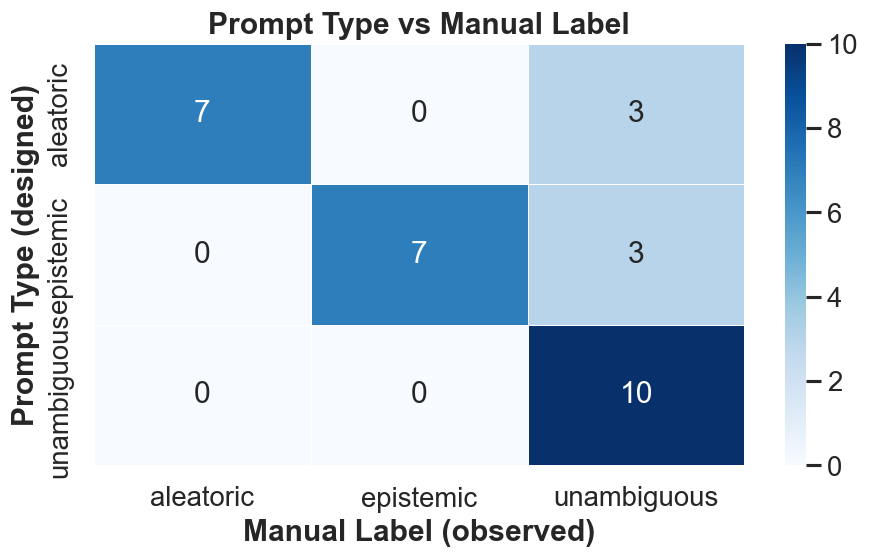

In [13]:
# Figure — confusion matrix: prompt_type vs manual_label
cross = pd.crosstab(
    labelled_df["prompt_type"],
    labelled_df["manual_label"],
    rownames=["Prompt Type (designed)"],
    colnames=["Manual Label (observed)"]
)
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(cross, annot=True, fmt="d", cmap="Blues", ax=ax, linewidths=0.5)
ax.set_title("Prompt Type vs Manual Label")
save_and_show(fig, "01_label_confusion_matrix.png")


C:\Users\dagxx\AppData\Local\Temp\ipykernel_3784\3345660868.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


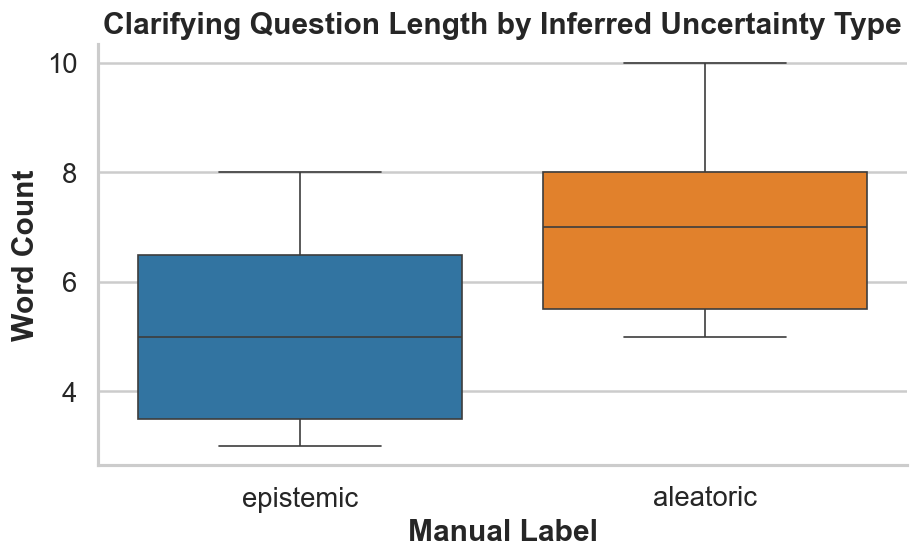

In [14]:
# Figure — CQ word length by manual label (epistemic vs aleatoric only)
plot_df = labelled_df[labelled_df["manual_label"].isin(QUESTION_TYPES)]
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=plot_df, x="manual_label", y="cq_word_count",
    palette=PALETTE, ax=ax
)
ax.set_title("Clarifying Question Length by Inferred Uncertainty Type")
ax.set_xlabel("Manual Label")
ax.set_ylabel("Word Count")
save_and_show(fig, "02_cq_length_by_label.png")


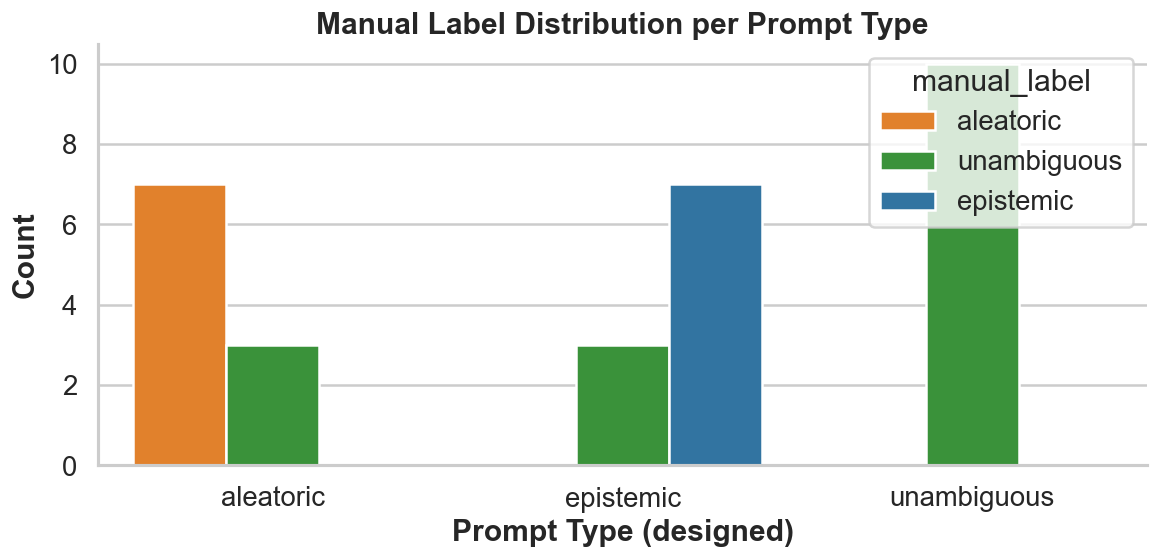

In [15]:
# Figure — label distribution grouped bar
group_counts = labelled_df.groupby(["prompt_type", "manual_label"]).size().reset_index(name="count")
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=group_counts, x="prompt_type", y="count", hue="manual_label",
    palette=PALETTE, ax=ax
)
ax.set_title("Manual Label Distribution per Prompt Type")
ax.set_xlabel("Prompt Type (designed)")
ax.set_ylabel("Count")
save_and_show(fig, "03_label_distribution.png")


---
# Phase 2 — Uncertainty Quantification

Generate **5 responses per prompt** at **temperature=0.8** to measure output variation.

Variation is computed as:
- `mean_bertscore` — average pairwise BERTScore F1 across the 5 runs (10 pairs)
- `mean_rougeL` — average pairwise ROUGE-L F1 as a lightweight complement
- `variation_score` = `1 - mean_bertscore` (higher = more variation)

If `outputs/variation_runs.csv` already exists the generation step is skipped.
Set `REGENERATE_PHASE2 = True` to force regeneration.


In [20]:
REGENERATE_PHASE2 = False  # set to True to force regeneration

if VARIATION_RUNS_PATH.exists() and not REGENERATE_PHASE2:
    variation_runs_df = pd.read_csv(VARIATION_RUNS_PATH)
    variation_runs_df["prompt_id"] = variation_runs_df["prompt_id"].astype(int)
    print(f"Loaded existing Phase 2 runs from {VARIATION_RUNS_PATH}")
else:
    records = []
    total = len(prompts_df) * N_VARIATION_RUNS
    done = 0
    for row in prompts_df.itertuples(index=False):
        for run_idx in range(1, N_VARIATION_RUNS + 1):
            cq = call_model(row.prompt_text, temperature=PHASE2_TEMPERATURE)
            records.append({"prompt_id": row.prompt_id, "run_index": run_idx, "generated_cq": cq})
            done += 1
            print(f"Phase 2: {done}/{total} — prompt {row.prompt_id} run {run_idx}")
            time.sleep(REQUEST_INTERVAL_SECONDS)
        # Save incrementally after each prompt
        pd.DataFrame(records).to_csv(VARIATION_RUNS_PATH, index=False)
    variation_runs_df = pd.DataFrame(records)
    print(f"Saved to {VARIATION_RUNS_PATH}")

variation_runs_df["generated_cq"] = variation_runs_df["generated_cq"].fillna("").astype(str).map(clean_text)
print(f"Total variation runs loaded: {len(variation_runs_df)}")
display(variation_runs_df.head(15))


Phase 2: 1/120 — prompt 1 run 1
Phase 2: 2/120 — prompt 1 run 2
Phase 2: 3/120 — prompt 1 run 3
Phase 2: 4/120 — prompt 1 run 4
Phase 2: 5/120 — prompt 2 run 1
Phase 2: 6/120 — prompt 2 run 2
Phase 2: 7/120 — prompt 2 run 3
Phase 2: 8/120 — prompt 2 run 4
Phase 2: 9/120 — prompt 3 run 1
Phase 2: 10/120 — prompt 3 run 2
Phase 2: 11/120 — prompt 3 run 3
Phase 2: 12/120 — prompt 3 run 4
Phase 2: 13/120 — prompt 4 run 1
Phase 2: 14/120 — prompt 4 run 2
Phase 2: 15/120 — prompt 4 run 3
Phase 2: 16/120 — prompt 4 run 4
Phase 2: 17/120 — prompt 5 run 1
Phase 2: 18/120 — prompt 5 run 2
Phase 2: 19/120 — prompt 5 run 3
Phase 2: 20/120 — prompt 5 run 4
Phase 2: 21/120 — prompt 6 run 1
Phase 2: 22/120 — prompt 6 run 2
Phase 2: 23/120 — prompt 6 run 3
Phase 2: 24/120 — prompt 6 run 4
Phase 2: 25/120 — prompt 7 run 1
Phase 2: 26/120 — prompt 7 run 2
Phase 2: 27/120 — prompt 7 run 3
Phase 2: 28/120 — prompt 7 run 4
Phase 2: 29/120 — prompt 8 run 1
Phase 2: 30/120 — prompt 8 run 2
Phase 2: 31/120 — p

,prompt_id,run_index,generated_cq
0,1,1,Is Kordemia a real-world country or region?
1,1,2,What is Kordemia?
2,1,3,What is Kordemia?
3,1,4,What is Kordemia?
4,2,1,What field or context are you referring to when?
5,2,2,NO_CLARIFICATION_NEEDED
6,2,3,Are you referring to the Verlinde formula or c...
7,2,4,"What field or context is the ""Verl?"
8,3,1,"Is the ""Drexel-9?"
9,3,2,What is the context or source of information f...


In [26]:
# Compute pairwise BERTScore and ROUGE-L per prompt
# Logic:
# - All 5 runs NO_CLARIFICATION_NEEDED → excluded from variation, flagged as suppressed if epistemic/aleatoric
# - Some runs NO_CLARIFICATION_NEEDED → compute variation on question runs only
# - All 5 runs produced questions → compute variation normally

variation_records = []

for prompt_id, group in variation_runs_df.groupby("prompt_id"):
    texts = group["generated_cq"].tolist()
    prompt_row = prompts_df[prompts_df["prompt_id"] == prompt_id].iloc[0]
    prompt_type = prompt_row["prompt_type"]

    questions_only = [t for t in texts if not is_no_clarification(t)]
    no_clarif_count = len(texts) - len(questions_only)

    # Suppressed = model returned NO_CLARIFICATION_NEEDED on a prompt that should trigger uncertainty
    suppressed = (len(questions_only) == 0) and (prompt_type in QUESTION_TYPES)

    if len(questions_only) < 2:
        variation_records.append({
            "prompt_id": prompt_id,
            "prompt_type": prompt_type,
            "mean_bertscore": np.nan,
            "mean_rougeL": np.nan,
            "variation_score": np.nan,
            "no_clarif_runs": no_clarif_count,
            "question_runs": len(questions_only),
            "excluded": True,
            "suppressed": suppressed,
        })
        continue

    rougeL_scores = [
        rouge_l_f1(a, b)
        for a, b in itertools.combinations(questions_only, 2)
    ]
    mean_rougeL = float(np.mean(rougeL_scores))

    pairs = list(itertools.combinations(questions_only, 2))
    refs = [p[0] for p in pairs]
    hyps = [p[1] for p in pairs]
    _, _, F1 = bertscore_score(hyps, refs, lang="en", verbose=False)
    mean_bs = float(F1.mean().item())

    variation_records.append({
        "prompt_id": prompt_id,
        "prompt_type": prompt_type,
        "mean_bertscore": mean_bs,
        "mean_rougeL": mean_rougeL,
        "variation_score": 1.0 - mean_bs,
        "no_clarif_runs": no_clarif_count,
        "question_runs": len(questions_only),
        "excluded": False,
        "suppressed": False,
    })

variation_scores_df = pd.DataFrame(variation_records)
variation_scores_df["prompt_id"] = variation_scores_df["prompt_id"].astype(int)
variation_scores_df.to_csv(VARIATION_SCORES_PATH, index=False)

print(f"Total prompts: {len(variation_scores_df)}")
print(f"Included in variation analysis: {(~variation_scores_df['excluded']).sum()}")
print(f"Excluded (insufficient question runs): {variation_scores_df['excluded'].sum()}")
print(f"\nSuppressed uncertainty (epistemic/aleatoric but all runs NO_CLARIFICATION_NEEDED):")
suppressed_df = variation_scores_df[variation_scores_df["suppressed"]]
print(suppressed_df[["prompt_id", "prompt_type", "no_clarif_runs"]].to_string(index=False))
print()
display(variation_scores_df.sort_values("variation_score", ascending=False, na_position="last"))

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 1790.18it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 389/389 [00:00<00:00, 2151.99it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status    

Total prompts: 30
Included in variation analysis: 14
Excluded (insufficient question runs): 16

Suppressed uncertainty (epistemic/aleatoric but all runs NO_CLARIFICATION_NEEDED):
 prompt_id prompt_type  no_clarif_runs
         4   epistemic               4
         7   epistemic               4
         8   epistemic               4
        12   aleatoric               4



,prompt_id,prompt_type,mean_bertscore,mean_rougeL,variation_score,no_clarif_runs,question_runs,excluded,suppressed
15,16,aleatoric,0.853663,0.000000,0.146337,2,2,False,False
9,10,epistemic,0.859146,0.179937,0.140854,0,4,False,False
1,2,epistemic,0.868312,0.319444,0.131688,1,3,False,False
2,3,epistemic,0.871354,0.267949,0.128646,1,3,False,False
4,5,epistemic,0.900082,0.235897,0.099918,0,4,False,False
8,9,epistemic,0.922711,0.555429,0.077289,0,4,False,False
0,1,epistemic,0.933937,0.500000,0.066063,0,4,False,False
19,20,aleatoric,0.949794,0.663947,0.050206,0,4,False,False
14,15,aleatoric,0.971119,0.826316,0.028881,1,3,False,False
17,18,aleatoric,0.974401,0.500000,0.025599,0,4,False,False


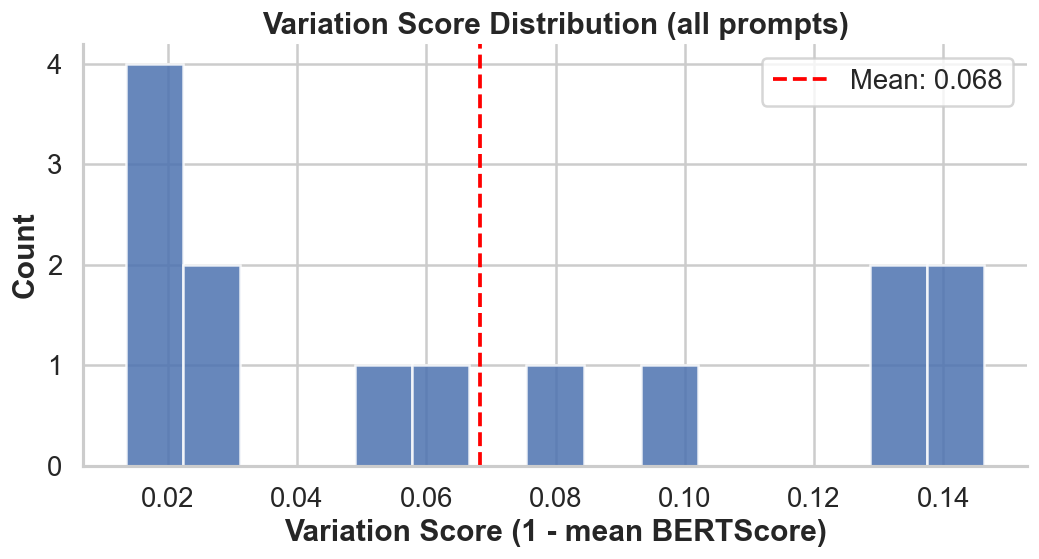

In [27]:
# Figure — variation score distribution
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(variation_scores_df["variation_score"], bins=15, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.axvline(variation_scores_df["variation_score"].mean(), color="red", linestyle="--",
           label=f"Mean: {variation_scores_df['variation_score'].mean():.3f}")
ax.set_title("Variation Score Distribution (all prompts)")
ax.set_xlabel("Variation Score (1 - mean BERTScore)")
ax.set_ylabel("Count")
ax.legend()
save_and_show(fig, "04_variation_score_distribution.png")


In [29]:
# Merge variation scores with labelled data
final_df = labelled_df.merge(
    variation_scores_df.drop(columns=["prompt_type"]),
    on="prompt_id",
    how="inner"
)

# ── Suppression rate analysis ──────────────────────────────────────────────
display(Markdown("### Suppression Rate (model returned NO_CLARIFICATION_NEEDED on uncertainty prompts)"))
for ptype in QUESTION_TYPES:
    subset = final_df[final_df["prompt_type"] == ptype]
    suppression_rate = subset["suppressed"].mean()
    print(f"  {ptype}: {suppression_rate:.1%} suppressed ({subset['suppressed'].sum()}/{len(subset)})")

# ── Variation analysis — exclude NaNs ─────────────────────────────────────
display(Markdown("### Variation Analysis (prompts with at least 2 question runs)"))
included_df = final_df[~final_df["excluded"]].copy()
print(f"Prompts included: {len(included_df)} / {len(final_df)}")
print()

# Point-biserial correlation
binary_subset = included_df[included_df["manual_label"].isin(QUESTION_TYPES)].copy()
binary_subset["label_binary"] = binary_subset["manual_label"].map({"aleatoric": 0, "epistemic": 1})

if binary_subset["label_binary"].nunique() == 2 and len(binary_subset) >= 4:
    corr_result = pointbiserialr(binary_subset["label_binary"], binary_subset["variation_score"])
    display(Markdown(
        f"**Point-biserial correlation** (variation_score vs manual_label, epistemic=1 aleatoric=0): "
        f"r = {corr_result.statistic:.3f}, p = {corr_result.pvalue:.4f}"
    ))
    if corr_result.statistic > 0:
        print("Epistemic-labelled prompts tended to show HIGHER variation.")
    else:
        print("Aleatoric-labelled prompts tended to show HIGHER variation (or no difference).")
    if corr_result.pvalue < 0.05:
        print("Result is statistically significant (p < 0.05).")
    else:
        print("Result is NOT statistically significant — likely due to small sample size.")
else:
    print("Not enough data points for correlation — check how many prompts were excluded.")

# Mann-Whitney U
display(Markdown("**Mann-Whitney U test (epistemic vs aleatoric variation scores):**"))
for label_col in ["prompt_type", "manual_label"]:
    sub = included_df[included_df[label_col].isin(QUESTION_TYPES)]
    ep = sub.loc[sub[label_col] == "epistemic", "variation_score"].dropna()
    al = sub.loc[sub[label_col] == "aleatoric", "variation_score"].dropna()
    if len(ep) >= 2 and len(al) >= 2:
        result = mannwhitneyu(ep, al, alternative="two-sided")
        print(f"  grouped by {label_col}: U={result.statistic:.1f}, p={result.pvalue:.4f} "
              f"(n_epistemic={len(ep)}, n_aleatoric={len(al)})")
    else:
        print(f"  grouped by {label_col}: not enough data (n_epistemic={len(ep)}, n_aleatoric={len(al)})")

# Kruskal-Wallis across all three types
display(Markdown("**Kruskal-Wallis (all three prompt types, excluded NaNs):**"))
groups = []
labels_present = []
for lbl in VALID_TYPES:
    g = included_df.loc[included_df["prompt_type"] == lbl, "variation_score"].dropna()
    if len(g) >= 2:
        groups.append(g)
        labels_present.append(lbl)
if len(groups) >= 2:
    kw = kruskal(*groups)
    print(f"  groups={labels_present}, H={kw.statistic:.3f}, p={kw.pvalue:.4f}")
else:
    print("  Not enough groups with sufficient data for Kruskal-Wallis.")

### Suppression Rate (model returned NO_CLARIFICATION_NEEDED on uncertainty prompts)

  epistemic: 30.0% suppressed (3/10)
  aleatoric: 10.0% suppressed (1/10)


### Variation Analysis (prompts with at least 2 question runs)

Prompts included: 14 / 30



**Point-biserial correlation** (variation_score vs manual_label, epistemic=1 aleatoric=0): r = 0.471, p = 0.1044

Epistemic-labelled prompts tended to show HIGHER variation.
Result is NOT statistically significant — likely due to small sample size.


**Mann-Whitney U test (epistemic vs aleatoric variation scores):**

  grouped by prompt_type: U=38.0, p=0.0973 (n_epistemic=7, n_aleatoric=7)
  grouped by manual_label: U=32.0, p=0.1375 (n_epistemic=6, n_aleatoric=7)


**Kruskal-Wallis (all three prompt types, excluded NaNs):**

  groups=['epistemic', 'aleatoric'], H=2.976, p=0.0845


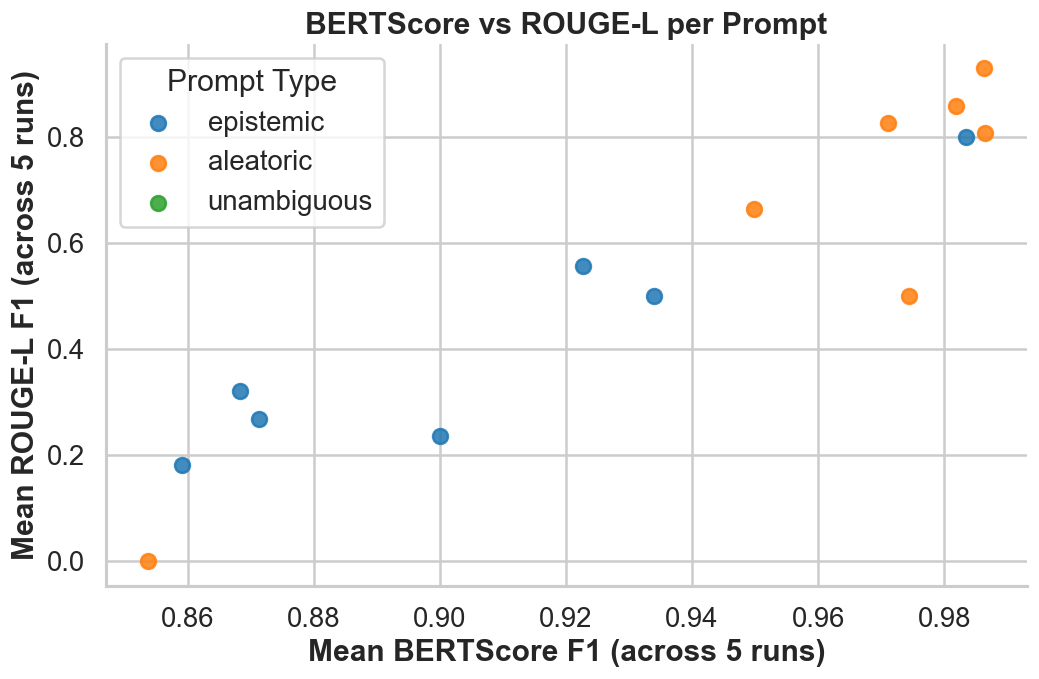

In [24]:
# Figure — BERTScore vs ROUGE-L scatter per prompt, coloured by prompt_type
fig, ax = plt.subplots(figsize=(9, 6))
for ptype in VALID_TYPES:
    subset = final_df[final_df["prompt_type"] == ptype]
    ax.scatter(
        subset["mean_bertscore"], subset["mean_rougeL"],
        label=ptype, color=PALETTE.get(ptype), s=80, alpha=0.85
    )
ax.set_title("BERTScore vs ROUGE-L per Prompt")
ax.set_xlabel("Mean BERTScore F1 (across 5 runs)")
ax.set_ylabel("Mean ROUGE-L F1 (across 5 runs)")
ax.legend(title="Prompt Type")
save_and_show(fig, "06_bertscore_vs_rougeL.png")


In [30]:
# Top 5 highest and lowest variation prompts
top5_high = final_df.nlargest(5, "variation_score")[["prompt_id", "prompt_type", "variation_score", "generated_cq"]]
top5_low = final_df.nsmallest(5, "variation_score")[["prompt_id", "prompt_type", "variation_score", "generated_cq"]]

display(Markdown("**Top 5 highest variation prompts:**"))
display(top5_high)
display(Markdown("**Top 5 lowest variation prompts:**"))
display(top5_low)


**Top 5 highest variation prompts:**

,prompt_id,prompt_type,variation_score,generated_cq
15,16,aleatoric,0.146337,Which version of Batman are you interested in?
9,10,epistemic,0.140854,"What is ""Veratinol""?"
1,2,epistemic,0.131688,NO_CLARIFICATION_NEEDED
2,3,epistemic,0.128646,What is the Drexel-9 microprocessor?
4,5,epistemic,0.099918,"What is ""Tarethia""?"


**Top 5 lowest variation prompts:**

,prompt_id,prompt_type,variation_score,generated_cq
18,19,aleatoric,0.013494,What are your friend's interests or hobbies?
12,13,aleatoric,0.013710,What genres do you usually enjoy?
5,6,epistemic,0.016496,What is the Mossfield protocol?
10,11,aleatoric,0.018075,Which airport are you trying to get to?
17,18,aleatoric,0.025599,What is your current location?


---
# Phase 3 — Correlation and Integration


In [33]:
# Point-biserial correlation: variation_score vs manual_label (epistemic=1, aleatoric=0)
binary_subset = final_df[final_df["manual_label"].isin(QUESTION_TYPES)].copy()
binary_subset["label_binary"] = binary_subset["manual_label"].map({"aleatoric": 0, "epistemic": 1})
binary_subset = binary_subset.dropna(subset=["variation_score"])

if binary_subset["label_binary"].nunique() == 2 and len(binary_subset) >= 4:
    corr_result = pointbiserialr(binary_subset["label_binary"], binary_subset["variation_score"])
    display(Markdown(
        f"**Point-biserial correlation** (variation_score vs manual_label, epistemic=1 aleatoric=0): "
        f"r = {corr_result.statistic:.3f}, p = {corr_result.pvalue:.4f}"
    ))
    if corr_result.statistic > 0:
        direction = "Epistemic-labelled prompts tended to show HIGHER variation."
    else:
        direction = "Aleatoric-labelled prompts tended to show HIGHER variation (or no difference)."
    print(direction)
    if corr_result.pvalue < 0.05:
        print("Result is statistically significant (p < 0.05).")
    else:
        print("Result is NOT statistically significant — likely due to small sample size.")
else:
    print("Not enough data points for correlation.")

print(f"\nbinary_subset used for correlation (n={len(binary_subset)}):")
print(binary_subset[["prompt_id", "prompt_type", "manual_label", "variation_score", "excluded", "suppressed"]])
print(f"\nNon-NaN variation scores: {binary_subset['variation_score'].notna().sum()}")
print(f"Unique labels: {binary_subset['label_binary'].unique()}")

**Point-biserial correlation** (variation_score vs manual_label, epistemic=1 aleatoric=0): r = 0.471, p = 0.1044

Epistemic-labelled prompts tended to show HIGHER variation.
Result is NOT statistically significant — likely due to small sample size.

binary_subset used for correlation (n=13):
    prompt_id prompt_type manual_label  variation_score  excluded  suppressed
0           1   epistemic    epistemic         0.066063     False       False
2           3   epistemic    epistemic         0.128646     False       False
4           5   epistemic    epistemic         0.099918     False       False
5           6   epistemic    epistemic         0.016496     False       False
8           9   epistemic    epistemic         0.077289     False       False
9          10   epistemic    epistemic         0.140854     False       False
10         11   aleatoric    aleatoric         0.018075     False       False
12         13   aleatoric    aleatoric         0.013710     False       False
14         15   aleatoric    aleatoric         0.028881     False       False
15         16   aleatoric    aleatoric   

In [34]:
def run_mannwhitney(df, label_col):
    sub = df[df[label_col].isin(QUESTION_TYPES)].dropna(subset=["variation_score"])
    ep = sub.loc[sub[label_col] == "epistemic", "variation_score"]
    al = sub.loc[sub[label_col] == "aleatoric", "variation_score"]
    if len(ep) < 2 or len(al) < 2:
        return {"grouping": label_col, "U": np.nan, "p_value": np.nan,
                "n_epistemic": len(ep), "n_aleatoric": len(al)}
    result = mannwhitneyu(ep, al, alternative="two-sided")
    return {"grouping": label_col, "U": result.statistic, "p_value": result.pvalue,
            "n_epistemic": len(ep), "n_aleatoric": len(al)}

def run_kruskal(df, label_col):
    groups = []
    labels_present = []
    for lbl in VALID_TYPES:
        g = df.loc[df[label_col] == lbl, "variation_score"].dropna()
        if len(g) >= 2:
            groups.append(g)
            labels_present.append(lbl)
    if len(groups) < 2:
        return {"grouping": label_col, "labels": ", ".join(labels_present),
                "H": np.nan, "p_value": np.nan}
    result = kruskal(*groups)
    return {"grouping": label_col, "labels": ", ".join(labels_present),
            "H": result.statistic, "p_value": result.pvalue}

mw_results = pd.DataFrame([
    run_mannwhitney(final_df, "prompt_type"),
    run_mannwhitney(final_df, "manual_label"),
])
display(Markdown("**Mann-Whitney U test (epistemic vs aleatoric):**"))
display(mw_results)

kw_results = pd.DataFrame([
    run_kruskal(final_df, "prompt_type"),
    run_kruskal(final_df, "manual_label"),
])
display(Markdown("**Kruskal-Wallis test (all three groups):**"))
display(kw_results)

**Mann-Whitney U test (epistemic vs aleatoric):**

,grouping,U,p_value,n_epistemic,n_aleatoric
0,prompt_type,38.0,0.097319,7,7
1,manual_label,32.0,0.137529,6,7


**Kruskal-Wallis test (all three groups):**

,grouping,labels,H,p_value
0,prompt_type,"epistemic, aleatoric",2.975510,0.084533
1,manual_label,"epistemic, aleatoric",2.469388,0.116083


C:\Users\dagxx\AppData\Local\Temp\ipykernel_3784\4049987205.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


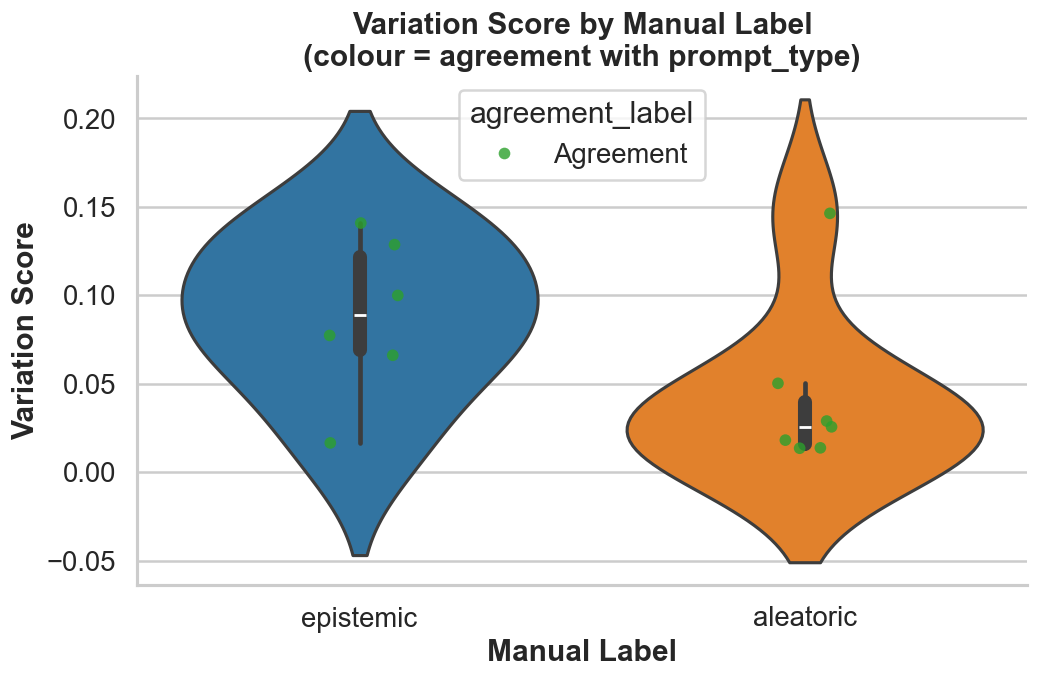

In [35]:
plot_df = final_df[final_df["manual_label"].isin(QUESTION_TYPES)].dropna(subset=["variation_score"]).copy()
plot_df["agreement_label"] = plot_df["agreement"].map({True: "Agreement", False: "Disagreement"})

fig, ax = plt.subplots(figsize=(9, 6))
sns.violinplot(
    data=plot_df, x="manual_label", y="variation_score",
    palette=PALETTE, inner="box", ax=ax
)
sns.stripplot(
    data=plot_df, x="manual_label", y="variation_score",
    hue="agreement_label", palette={"Agreement": "#2ca02c", "Disagreement": "#d62728"},
    dodge=False, alpha=0.8, size=7, ax=ax
)
ax.set_title("Variation Score by Manual Label\n(colour = agreement with prompt_type)")
ax.set_xlabel("Manual Label")
ax.set_ylabel("Variation Score")
save_and_show(fig, "07_violin_variation_by_label.png")

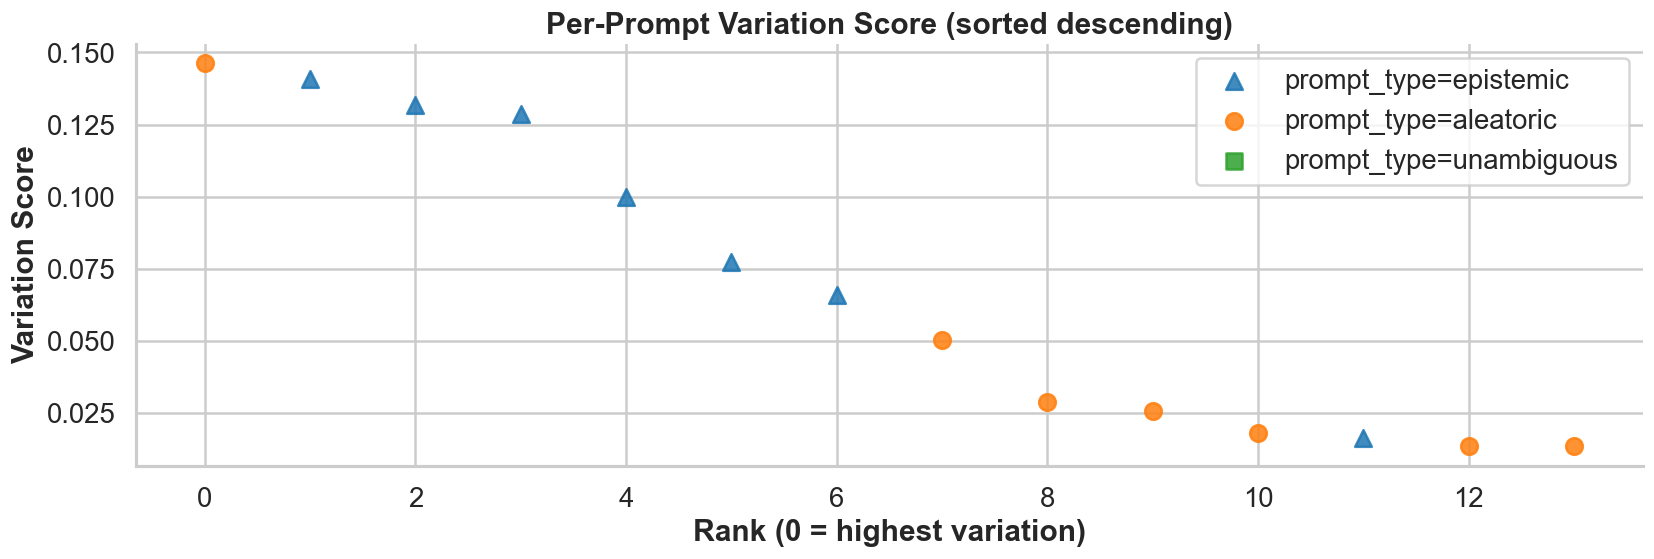

In [36]:
sorted_df = final_df.sort_values("variation_score", ascending=False, na_position="last").reset_index(drop=True)
marker_map = {"epistemic": "^", "aleatoric": "o", "unambiguous": "s"}

fig, ax = plt.subplots(figsize=(14, 5))
for ptype in VALID_TYPES:
    subset = sorted_df[sorted_df["prompt_type"] == ptype]
    ax.scatter(
        subset.index, subset["variation_score"],
        label=f"prompt_type={ptype}",
        color=PALETTE.get(ptype),
        marker=marker_map.get(ptype, "o"),
        s=100, alpha=0.85
    )
ax.set_title("Per-Prompt Variation Score (sorted descending)")
ax.set_xlabel("Rank (0 = highest variation)")
ax.set_ylabel("Variation Score")
ax.legend()
save_and_show(fig, "08_per_prompt_variation_scatter.png")

In [37]:
# Final summary table
summary_cols = ["prompt_id", "prompt_type", "manual_label", "agreement",
                "variation_score", "mean_bertscore", "generated_cq", "variety"]
summary_cols = [c for c in summary_cols if c in final_df.columns]
summary_table = final_df[summary_cols].sort_values("variation_score", ascending=False)

display(Markdown("**Final summary table (sorted by variation_score descending):**"))
display(summary_table)

summary_table.to_csv(OUTPUT_DIR / "phase3_summary_table.csv", index=False)
print(f"Saved to {OUTPUT_DIR / 'phase3_summary_table.csv'}")


**Final summary table (sorted by variation_score descending):**

,prompt_id,prompt_type,manual_label,agreement,variation_score,mean_bertscore,generated_cq,variety
15,16,aleatoric,aleatoric,True,0.146337,0.853663,Which version of Batman are you interested in?,discrete disambiguation — multiple known valid...
9,10,epistemic,epistemic,True,0.140854,0.859146,"What is ""Veratinol""?",fabricated drug name
1,2,epistemic,unambiguous,False,0.131688,0.868312,NO_CLARIFICATION_NEEDED,fabricated concept
2,3,epistemic,epistemic,True,0.128646,0.871354,What is the Drexel-9 microprocessor?,fabricated technical entity
4,5,epistemic,epistemic,True,0.099918,0.900082,"What is ""Tarethia""?",fabricated event
8,9,epistemic,epistemic,True,0.077289,0.922711,What is the correct spelling of the city?,plausible but fabricated place
0,1,epistemic,epistemic,True,0.066063,0.933937,Could you please specify what Kordemia refers to?,fabricated entity
19,20,aleatoric,aleatoric,True,0.050206,0.949794,Who are you referring to?,referential ambiguity — pronoun with no antece...
14,15,aleatoric,aleatoric,True,0.028881,0.971119,What is the age of the person experiencing the...,missing personal and clinical context
17,18,aleatoric,aleatoric,True,0.025599,0.974401,What is your current location?,missing spatial context


Saved to d:\final_project\pilot_study\outputs\phase3_summary_table.csv


## Extra

In [38]:
# ── INVESTIGATE NO_CLARIFICATION_NEEDED RESPONSES ─────────────────────────
# For every prompt where the model returned NO_CLARIFICATION_NEEDED,
# ask the model to just answer the question directly and print what it says.
# This lets us see if the answer makes sense — especially for epistemic prompts
# where the model should NOT have been able to answer confidently.
# ──────────────────────────────────────────────────────────────────────────

no_clarif_prompts = labelled_df[labelled_df["returned_no_clarification"] == True].copy()

print(f"Prompts that returned NO_CLARIFICATION_NEEDED: {len(no_clarif_prompts)}")
print(f"  Expected (unambiguous control): {(no_clarif_prompts['prompt_type'] == 'unambiguous').sum()}")
print(f"  Unexpected (epistemic):         {(no_clarif_prompts['prompt_type'] == 'epistemic').sum()}")
print(f"  Unexpected (aleatoric):         {(no_clarif_prompts['prompt_type'] == 'aleatoric').sum()}")
print()

answers = []
for row in no_clarif_prompts.itertuples(index=False):
    response = client.models.generate_content(
        model=MODEL_ID,
        contents=row.prompt_text,
        config=types.GenerateContentConfig(
            temperature=0.0,
            max_output_tokens=512,
        ),
    )
    # Extract non-thinking part
    answer_text = ""
    for part in response.candidates[0].content.parts:
        if not getattr(part, "thought", False):
            answer_text = clean_text(part.text)
            break

    answers.append({
        "prompt_id": row.prompt_id,
        "prompt_type": row.prompt_type,
        "prompt_text": row.prompt_text,
        "model_answer": answer_text,
    })

    expected = "✓ correct" if row.prompt_type == "unambiguous" else "✗ SHOULD HAVE ASKED"
    print(f"[{expected}] Prompt {row.prompt_id} ({row.prompt_type})")
    print(f"  Q: {row.prompt_text}")
    print(f"  A: {answer_text[:300]}")
    print()
    time.sleep(REQUEST_INTERVAL_SECONDS)

answers_df = pd.DataFrame(answers)
answers_df.to_csv(OUTPUT_DIR / "no_clarification_answers.csv", index=False)
print(f"Saved to {OUTPUT_DIR / 'no_clarification_answers.csv'}")

Prompts that returned NO_CLARIFICATION_NEEDED: 16
  Expected (unambiguous control): 10
  Unexpected (epistemic):         3
  Unexpected (aleatoric):         3

[✗ SHOULD HAVE ASKED] Prompt 2 (epistemic)
  Q: Explain the Verlinden compression theorem and its applications.
  A: It appears there might be a misunderstanding or a misremembered term, as there is **no widely

[✗ SHOULD HAVE ASKED] Prompt 7 (epistemic)
  Q: What is the boiling point of flerovium under standard atmospheric pressure?
  A: The boiling point of flerovium (Fl) under standard atmospheric pressure is **unknown**. Here'

[✗ SHOULD HAVE ASKED] Prompt 8 (epistemic)
  Q: Who won the 2031 FIFA World Cup and what was the final score?
  A: The FIFA World Cup is held every four years, so there was no FIFA World Cup in 2031. The most recent World Cup was in 2022, and the next ones are scheduled for: * **2026** (hosted by Canada, Mexico, and the United States) * **2030** (co-hosted by Morocco, Portugal, and Spain, with opening

---
## Reflection

Fill in after reviewing all outputs.

### Did the labels feel natural to assign?
_Your notes here._

### Which cases were hardest to classify and why?
_Your notes here._

### Did epistemic and aleatoric prompts vary differently as hypothesised?
_Your notes here._

### How did the unambiguous control prompts behave?
_Your notes here._

### What does the correlation result suggest about the core research idea?
_Your notes here._

### Go or no-go for the full benchmark?
_Your notes here._
